## 这份代码在做什么  
你要预测加州房价（回归问题） 

Baseline：只用原始特征（例如收入、房间数、纬度经度…）训练 ANN  

Enhanced：在原始特征基础上，额外加一列**“邻居平均房价”**（用地理位置找附近的房子，把这些邻居的训练房价取平均），再训练 ANN  

最后比较两者的 Test MSE，看加邻域特征有没有让模型更准。


## method  
我们的方法在 baseline ANN 的基础上加入了一个基于 “地理邻域” 的特征来显式建模空间相关性。   

虽然原始特征中已包含纬度与经度，但仅将它们作为普通数值输入会要求模型自行学习复杂的“位置—房价”非线性关系。例如靠海房价贵，经纬度接近的房子房价也接近等。  

为此，我们使用纬度/经度在空间中为每个样本定义k-近邻，并用训练集中这些邻居的目标值（房价中位数）计算邻域平均，得到新特征 Avg_Neighbor_Price。 
 
该特征作为额外输入与原始特征一同输入到同结构的 ANN 中，从而为模型提供“附近地区价格相近”的先验信息，提升对位置效应的表达能力，同时在测试集上构造该特征时仅使用训练集标签以避免数据泄露。

## 1. 导入库
numpy (np)：数学计算用的，尤其是 mean、数组索引等  
pandas (pd)：表格数据工具（DataFrame），像 Excel 那种结构  
matplotlib.pyplot (plt)：画图用（散点图、直线等）  

scikit-learn 这些：  
fetch_california_housing：下载/读取 California Housing 数据集（已经内置）  
train_test_split：把数据随机分成训练集/测试集  
StandardScaler：做标准化（让特征均值=0，方差=1），神经网络很需要这个  
MLPRegressor：前馈神经网络（ANN）做回归  
mean_squared_error：算 MSE（均方误差）  
NearestNeighbors：KNN 找最近的邻居（你用经纬度找附近地区）  

In [1]:
# To make sure everyone has these necessary modules
%pip install numpy pandas matplotlib scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 44.8 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 82.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 72.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 60.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 100.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 59.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 30.2 MB/s  0:00:00m eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 63.0 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13/13 [matplotlib]3 [matplotlib]n]

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error
from sklearn.neighbors import NearestNeighbors

from sklearn.ensemble import GradientBoostingRegressor


## 2. 读取数据：X是特征，y是答案  
X：输入特征（每一行是一块区域的统计信息），比如：  
	•	MedInc（中位收入）  
	•	HouseAge（房龄）  
	•	AveRooms（平均房间数）  
	•	Latitude / Longitude（纬度经度）等等  

y：目标值（你要预测的真实房价标签），一个一维数组。


In [3]:
# Load data
data = fetch_california_housing()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target  # median house value

print("Original X (head):")
print(X.head())

Original X (head):
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  


## 3. 切分训练集/测试集。
test_size=0.2：20% 做测试集，80% 做训练集  
random_state=42：固定随机种子，保证你每次跑切分结果都一样（方便写报告、复现）。

#### 为什么要切分（split）  
因为你后面要做“邻居平均房价”这个特征，如果你不先 split，很容易把测试集的真实房价 y_test 偷偷用进来，这叫 data leakage（数据泄露），会让结果看起来特别好但其实作弊了。  

你现在的写法是正确的：  
✅ 先 split  
✅ 用训练集构造特征  
✅ 测试集只能“借用训练集的信息”，不能用测试集真实标签

In [4]:
# Train/test split (avoid leakage)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## 4.核心： 邻域特征add_graph_features  
#### 4.1 直觉理解  
房价强烈跟地理位置相关：  
你住伦敦一区，隔壁一区差不多也贵；你住郊区，隔壁郊区也差不多便宜。  
所以我们给每一条数据加一个新特征：  
Avg_Neighbor_Price = “附近 k 个邻居的平均房价”  
这样神经网络不需要自己从经纬度“猜”空间规律，我们直接把空间规律喂给它。  

#### 4.2 函数代码讲解  
见代码  

#### * 为什么要k+1  
当你给训练集加特征时：df 和 reference_df 是同一个集合。  
那 KNN 找最近邻时，第一个邻居往往就是它自己（距离=0）。  
如果你不排除它自己，那么：  
Avg_Neighbor_Price = mean( [自己的y, 邻居1的y, 邻居2的y, …] )  
这会让新特征更像“答案本身”，会让 enhanced 的效果“看起来更强”（偏虚高）。  
所以我们做：  
	•	先找 k+1 个邻居  
	•	把第一个（自己）丢掉  
	•	剩下 k 个再平均  



In [5]:
def add_graph_features(df, reference_df, reference_y, k=5, exclude_self=False):
    """Add a simple neighbourhood feature based on geographic kNN.

    Parameters
    ----------
    df : pd.DataFrame
        The dataset to which we want to add the feature (train or test).
    reference_df : pd.DataFrame
        The pool of candidate neighbours (typically the training set only).
    reference_y : array-like
        Target values aligned with reference_df (must be y_train to avoid leakage).
    k : int, default=5
        Number of neighbours used to compute the neighbourhood statistic.
    exclude_self : bool, default=False
        If True (typically for training set when df == reference_df), drop the closest
        neighbour which is usually the point itself.

    Returns
    -------
    pd.DataFrame or None
        A copy of df with an added column 'Avg_Neighbor_Price'. Returns None for invalid input.
    """
    # Defensive checks (match assignment-style behaviour used elsewhere in this notebook)
    if df is None or reference_df is None or reference_y is None:
        return None
    if len(df) == 0:
        out = df.copy()
        out['Avg_Neighbor_Price'] = np.array([])
        return out

    # 1) Coordinates for neighbour search (lat/long)
    coords_ref = reference_df[['Latitude', 'Longitude']].to_numpy()
    coords_target = df[['Latitude', 'Longitude']].to_numpy()

    # 2) If excluding self, grab one extra neighbour then drop the first one
    n_neighbors = k + 1 if exclude_self else k

    # 3) Fit neighbour index once, then query all targets
    nbrs = NearestNeighbors(n_neighbors=n_neighbors).fit(coords_ref)
    _distances, indices = nbrs.kneighbors(coords_target)

    # 4) Vectorised average neighbour price (faster + cleaner than Python loops)
    if exclude_self:
        indices = indices[:, 1:]
    ref_y = np.asarray(reference_y)
    avg_neighbor_price = ref_y[indices].mean(axis=1)

    out = df.copy()
    out['Avg_Neighbor_Price'] = avg_neighbor_price
    return out


#### 4.3 用add_graph_features函数生成enhanced数据  
关键点：  
训练集 enhanced：邻居来自训练集本身，但排除自己（exclude_self=True）  
测试集 enhanced：邻居只能来自训练集（reference_df = X_train_raw, reference_y = y_train）  
✅ 不使用 y_test（避免泄露）

In [6]:
# Enhanced datasets
# - training enhanced excludes self
X_train_enhanced = add_graph_features(
    X_train_raw, X_train_raw, y_train, k=5, exclude_self=True
)
# - test enhanced uses ONLY training as reference (no leakage)
X_test_enhanced = add_graph_features(
    X_test_raw, X_train_raw, y_train, k=5, exclude_self=False
)

print("\nEnhanced X_train (head):")
print(X_train_enhanced.head())


Enhanced X_train (head):
       MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
14196  3.2596      33.0  5.017657   1.006421      2300.0  3.691814     32.71   
8267   3.8125      49.0  4.473545   1.041005      1314.0  1.738095     33.77   
17445  4.1563       4.0  5.645833   0.985119       915.0  2.723214     34.66   
14265  1.9425      36.0  4.002817   1.033803      1418.0  3.994366     32.69   
2271   3.5542      43.0  6.268421   1.134211       874.0  2.300000     36.78   

       Longitude  Avg_Neighbor_Price  
14196    -117.03              1.1614  
8267     -118.16              3.3092  
17445    -120.48              1.4200  
14265    -117.11              0.9806  
2271     -119.80              0.8496  


## 5. 定义神经网络：为什么抽成 build_mode  
这样做的意义：  
Baseline 和 Enhanced 用一模一样的网络结构，差异只来自“有没有邻域特征”。
这叫 fair comparison（公平比较）。 

参数解释：  
	•	hidden_layer_sizes=(64,32)：两层隐藏层  
	•	第一层 64 个神经元  
	•	第二层 32 个神经元  
	•	activation='relu'：激活函数 ReLU（非线性，神经网络的灵魂）  
	•	solver='adam'：优化器（训练时怎么更新参数）  
	•	alpha=1e-4：L2 正则化强度（防止过拟合的一点点约束）  
	•	max_iter=500：最多训练 500 次迭代  
	•	random_state=42：固定初始化随机性



In [7]:
#Model definition helper (same architecture for fair comparison)
def build_model(random_state=42):
    return MLPRegressor(
        hidden_layer_sizes=(64, 32),
        activation='relu',
        solver='adam',
        alpha=1e-4,
        max_iter=500,
        random_state=random_state
    )

In [8]:
def fit_predict_mse(model, X_train, y_train, X_test, y_test, scale=True, random_state=42):
    """Fit a regression model and return (mse, y_pred, fitted_scaler).

    Notes
    -----
    - For MLPRegressor we scale features (important).
    - For tree-based models we typically do NOT need scaling.
    """
    scaler = None
    if scale:
        scaler = StandardScaler()
        Xtr = scaler.fit_transform(X_train)
        Xte = scaler.transform(X_test)
    else:
        Xtr, Xte = X_train, X_test

    model.fit(Xtr, y_train)
    y_pred = model.predict(Xte)
    mse = mean_squared_error(y_test, y_pred)
    return mse, y_pred, scaler


## 6.Baseline：不加邻域特征，直接训练 ANN  

#### 6.1 标准化（重要）
为什么要标准化？  
神经网络训练是靠梯度下降，如果某个特征数值范围很大（比如收入 10100），另一个很小（比如经纬度 3040），训练会很不稳定、收敛慢、甚至效果差。  

关键点：  
	•	fit_transform 只对训练集做（学习均值方差并转换）  
	•	测试集只能 transform（用训练集的均值方差来变换）  
	•	✅ 这也是避免泄露（不能用测试集统计量）


In [9]:
# BASELINE: train ANN on original X (no graph features)
scaler_base = StandardScaler()
X_train_base_scaled = scaler_base.fit_transform(X_train_raw)
X_test_base_scaled = scaler_base.transform(X_test_raw)

#### 6.2 训练 + 预测 + MSE  
•fit：训练模型（学参数）  
•predict：预测测试集房价  
•MSE：衡量误差大小  
•越小越好  
•MSE 是平均平方误差：错误大的会被平方惩罚更重   


In [10]:
model_base = build_model(random_state=42)
model_base.fit(X_train_base_scaled, y_train)

y_pred_base = model_base.predict(X_test_base_scaled)
mse_base = mean_squared_error(y_test, y_pred_base)

## 7. Enhanced：加了 Avg_Neighbor_Price 再训练 ANN  
这一段和 baseline 完全同样流程，只是输入特征变成 X_train_enhanced / X_test_enhanced  

这里为什么要单独一个 scaler_enh？  
因为 enhanced 多了一列特征，维度不一样；不能用 baseline 的 scaler。

In [11]:
scaler_enh = StandardScaler()
X_train_enh_scaled = scaler_enh.fit_transform(X_train_enhanced)
X_test_enh_scaled = scaler_enh.transform(X_test_enhanced)

model_enh = build_model(random_state=42)
model_enh.fit(X_train_enh_scaled, y_train)

y_pred_enh = model_enh.predict(X_test_enh_scaled)
mse_enh = mean_squared_error(y_test, y_pred_enh)

## 8. 对比结果： MSE和提升百分比  
如果 enhanced 更好：mse_enh 更小 → improvement 是正数（提升%）  
如果 enhanced 更差：improvement 是负数（退步%）


In [12]:
improvement = (mse_base - mse_enh) / mse_base * 100

results = pd.DataFrame({
    "Model": ["Baseline (no graph feature)", "Enhanced (+Avg_Neighbor_Price)"],
    "Test MSE": [mse_base, mse_enh]
})

print(results)
print(f"\nRelative MSE improvement: {improvement:.2f}% (positive means enhanced is better)")


                            Model  Test MSE
0     Baseline (no graph feature)  0.274289
1  Enhanced (+Avg_Neighbor_Price)  0.180995

Relative MSE improvement: 34.01% (positive means enhanced is better)


## 9. 可视化：Actual vs Predicted 散点图看拟合质量
•	x轴：真实房价（Actual）  
•	y轴：预测房价（Predicted）  
•	红色虚线：理想情况 y=x（预测=真实）  
•	点越贴近红线 → 预测越准  
•	如果点整体偏离、或者形成弯曲 → 模型有系统性偏差  

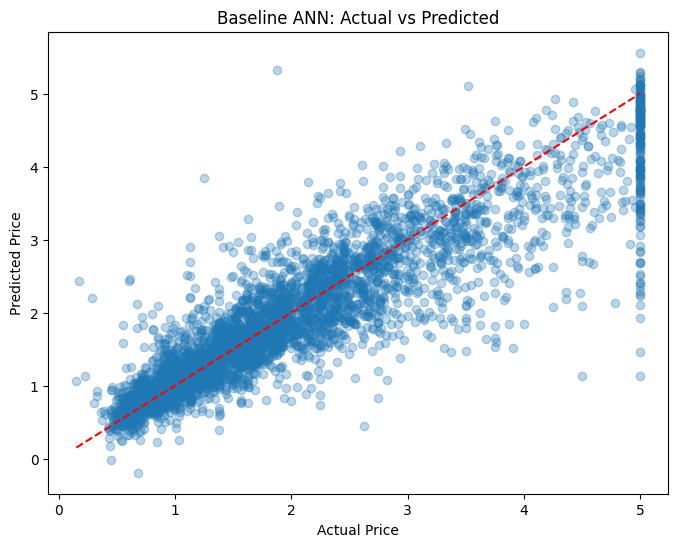

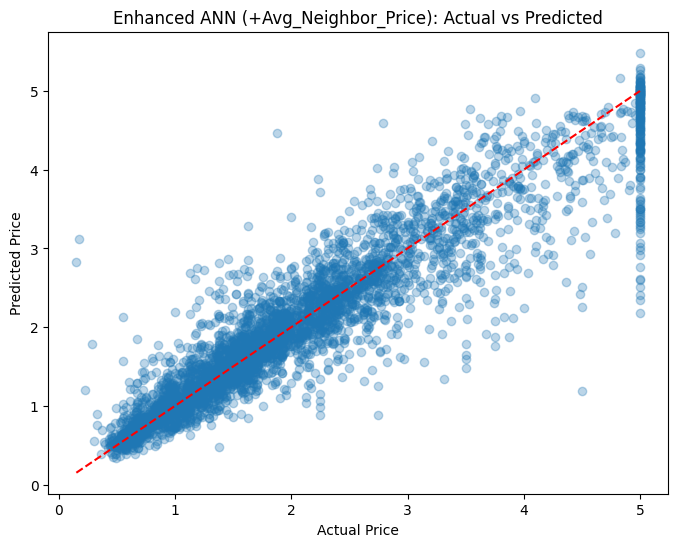

In [13]:
# Visualize (Actual vs Predicted)
def plot_actual_vs_pred(y_true, y_pred, title):
    plt.figure(figsize=(8, 6))
    plt.scatter(y_true, y_pred, alpha=0.3)
    # identity line
    mn, mx = float(np.min(y_true)), float(np.max(y_true))
    plt.plot([mn, mx], [mn, mx], 'r--')
    plt.xlabel("Actual Price")
    plt.ylabel("Predicted Price")
    plt.title(title)
    plt.show()

plot_actual_vs_pred(y_test, y_pred_base, "Baseline ANN: Actual vs Predicted")
plot_actual_vs_pred(y_test, y_pred_enh, "Enhanced ANN (+Avg_Neighbor_Price): Actual vs Predicted")

## 这张图每个东西代表什么？  
•	横轴 Actual Price：真实房价  
•	纵轴 Predicted Price：模型预测房价  
•	每一个点：测试集里的一条样本（一个地区）  
•	红色虚线：理想情况 预测房价y=真实房价y  
•	点越贴近红线 → 越准  
•	点离红线越远 → 误差越大  

关键判断规则：  
•	在线上方（点在红线之上）：预测 > 真实 → 高估  
•	在线下方（点在红线之下）：预测 < 真实 → 低估

#### Baseline plot  
1. 整体趋势是对的：点云整体沿着红线走，说明模型能抓到“房价越高，预测也越高”的趋势。  

2. 但误差会随着真实房价变大而变大：
	•	真实价格低（比如 0.5~2）的时候，点云比较紧  
	•	真实价格高（比如 3~5）的时候，点云更散  

3. 右边有一条“竖直的墙”在 Actual=5  
这通常代表：数据集的真实房价被上限截断（cap）了，很多样本的真实值都等于5（顶格）。  
于是你会看到：  
	•	真实=5 的点很多
	•	预测值却从大约 2.x 到 5.x 都有  
这类点会拉高 MSE，而且模型往往会低估顶格房价（因为它学不到“更高”到底有多高，只知道被截断了）。
这是数据本身的特点。  

#### Enhanced plot  
1. 点云更“贴红线”一些（更紧）  
尤其在 中间价位（大概 1~4），Enhanced 的点云通常会比 Baseline 更集中、更像一条带状贴着红线。  
这代表：加入邻域平均房价后，模型对“同一价位附近的样本”预测更稳定，误差变小。

2. 高价区（接近 5）的问题仍然在  
右侧 Actual=5 的竖线依旧存在，而且预测仍然分散——说明邻域特征虽然帮忙，但对顶格/极端高价的预测仍有限（原因还是 cap + 高价区噪声大）。  
	•	Enhanced 对大多数区域有改善  
	•	但对 cap 的极端高价样本改善有限 




In [14]:
cap = 5.0
mask_cap = np.isclose(y_test, cap, atol=1e-8)

print("Proportion capped at 5:", np.mean(mask_cap))

mse_cap = mean_squared_error(y_test[mask_cap], y_pred_enh[mask_cap])
mse_noncap = mean_squared_error(y_test[~mask_cap], y_pred_enh[~mask_cap])

print("MSE (capped=5):", mse_cap)
print("MSE (non-capped):", mse_noncap)

Proportion capped at 5: 0.044573643410852716
MSE (capped=5): 0.7649666716803329
MSE (non-capped): 0.15375131288458949


A noticeable vertical band at Actual = 5 indicates that the target variable is capped at 5 for a subset of observations. A noticeable vertical band at Actual = 5 indicates that the target variable is capped at 5 for a subset of observations. This censoring limits the model’s ability to learn fine-grained differences among the most expensive areas. In our test set, about **4.46%** of samples are capped at 5, and the prediction error on capped samples (MSE ≈ **0.765**) is substantially larger than on non-capped samples (MSE ≈ **0.154**). Therefore, while overall performance improves with the neighbourhood feature, predictions at the upper end remain challenging due to target censoring.  
从 Actual vs Predicted 图中可以看到在 Actual≈5 附近存在明显的竖直带，说明目标变量在最大值处存在封顶/截断。用 np.isclose 判断后，测试集中约 4.46% 的样本属于顶格（y≈5）。顶格样本的误差明显更大（MSE≈0.765），而非顶格样本误差较小（MSE≈0.154），说明模型的总体误差很大一部分来自高价端的封顶区域，高价预测依然是主要难点。

## 10. 进一步改善模型，adjust k-value

In [15]:
ks = [5, 25, 50, 100, 500]
k_results = []

for k in ks:
    # 1) Build enhanced features for this k (train excludes self; test uses train pool)
    X_train_en = add_graph_features(X_train_raw, X_train_raw, y_train, k=k, exclude_self=True)
    X_test_en  = add_graph_features(X_test_raw,  X_train_raw, y_train, k=k, exclude_self=False)

    # 2) Fit + predict + evaluate (MLP needs scaling)
    model = build_model(random_state=42)
    mse, y_pred, scaler = fit_predict_mse(model, X_train_en, y_train, X_test_en, y_test, scale=True)

    k_results.append((k, mse))
    print(f"k={k:>3d} -> Test MSE = {mse:.4f}")

# Convenient view
k_results_df = pd.DataFrame(k_results, columns=["k", "test_mse"]).sort_values("test_mse")
k_results_df


k=  5 -> Test MSE = 0.1810
k= 25 -> Test MSE = 0.1949
k= 50 -> Test MSE = 0.2009
k=100 -> Test MSE = 0.2177
k=500 -> Test MSE = 0.2371


,k,test_mse
0,5,0.180995
1,25,0.194918
2,50,0.200948
3,100,0.217710
4,500,0.237126


#### 通过adjust k-value的发现：  
1. 存在一个“较优的 k”（通常在小 k）。测试了多个 k 值，发现模型在较小的 k（例如 5/25）时表现最好；当 k 变大时，测试误差上升。  
2. k 在中等范围变化时，点云图肉眼差别不明显。说明在该设置下模型对 k 的变化并不“极度敏感”；差异主要体现在 MSE 的小幅变化上。  
3. 当 k 很大时，Avg_Neighbor_Price 更接近一个“更大范围/更全局的平均价格”，会把局部街区差异抹平（over-smoothing）。因此邻域特征变得不够“本地”，对预测帮助变小甚至变差。

## 11. 尝试使用“多尺度 + 距离加权”的邻域特征  
现在的 Avg_Neighbor_Price 其实是：  
•	只用 一个尺度（一个 k）  
•	而且是 简单平均（不管远近）

修改为：  
•	用权重 w=1/(d+\epsilon) 做加权平均。
近的邻居权重大，远的权重小。   
•	同时算多区域价位（就是把原始代码+k set的loop code block合为一个整体的意思）


In [16]:
def add_weighted_neighbor_feature(df, reference_df, reference_y, k=5, exclude_self=False, eps=1e-6):
    """Add a distance-weighted neighbour price feature.

    We compute weights w = 1/(d + eps), then:
        Weighted_Neighbor_Price = sum(w_i * y_i) / sum(w_i)

    Parameters and validity handling match add_graph_features.
    """
    if df is None or reference_df is None or reference_y is None:
        return None
    if len(df) == 0:
        out = df.copy()
        out['Weighted_Neighbor_Price'] = np.array([])
        return out

    coords_ref = reference_df[['Latitude', 'Longitude']].to_numpy()
    coords_target = df[['Latitude', 'Longitude']].to_numpy()

    n_neighbors = k + 1 if exclude_self else k
    nbrs = NearestNeighbors(n_neighbors=n_neighbors).fit(coords_ref)
    distances, indices = nbrs.kneighbors(coords_target)

    if exclude_self:
        distances = distances[:, 1:]
        indices = indices[:, 1:]

    ref_y = np.asarray(reference_y)
    neigh_y = ref_y[indices]

    weights = 1.0 / (distances + eps)
    weighted_avg = (weights * neigh_y).sum(axis=1) / weights.sum(axis=1)

    out = df.copy()
    out['Weighted_Neighbor_Price'] = weighted_avg
    return out


#### 通过 Multi-scale, Distance-weighted Graph Features 的发现：  
分析原因A：  
•	经纬度是“平面欧氏距离”，不等于真实地理距离。NearestNeighbors 默认用欧氏距离算（lat/long 的差）。  
•	但经纬度其实是在球面上，尤其经度在不同纬度下“1度代表的距离不一样”。  
•	所以使用 1/(distance) 加权，会把这种“距离的误差”放大：权重更敏感，误差也被放大。

分析原因B：  
•	权重太尖锐（closest 1–2 个邻居影响过大）  
•	1/(d+eps) 会让最近的点权重非常大，导致：  
	•	特征变得更像“最近邻的 y”，对噪声特别敏感  
	•	一旦最近邻不是同一真实子市场（比如隔一条山/河/城市边界），就会被误导

分析原因C：
•	已经在 X 里有 Latitude/Longitude 了。ANN 已经能利用经纬度，再加一个过强的加权邻域价，会容易让模型“过度依赖邻域价”，泛化变差。

k越大MSE越小的原因分析：  
•	你用的权重一般是类似 w=1/(d+\epsilon)。
这会导致：距离最小的 1–2 个点权重巨大，远一点的点权重很小。 所以当 k 很小（比如 5）时，加权平均几乎变成：“最接近的 1–2 个邻居的价格（几乎就是它们在决定）”  
如果这些最近邻刚好是噪声点、或者处在价格跳变边界（城市边界/地形/学区），那你这个特征就会很不稳定 → MSE 高。
•	增大 k 会引入更多邻居使加权统计更平滑，从而降低方差并改善测试误差，因此在加权设置下观察到 k 越大 MSE 越小的趋势。


#### 比较两种邻域特征：  
简单平均和距离加权平均。简单平均更平滑、更抗噪，作为 ANN 输入时更稳定；距离加权更强调最近邻，信息更“尖锐”，但也更容易受距离度量误差和局部噪声影响。实验中距离加权并未带来提升，反而增加了测试误差，说明在本数据中简单平均更适合用于邻域特征。

## 12. 拓展模型：树模型（Gradient Boosting） + 邻域特征  
前面我们用的是 ANN（MLPRegressor）。这里再加一个 **非神经网络** 的回归模型做对照：  
- 树模型对特征缩放不敏感（一般不需要 StandardScaler）  
- 能捕捉非线性与特征交互  
- 可以验证：邻域特征提升是否“只对 ANN 有效”，还是对别的模型也有用  


In [17]:
# Gradient Boosting Regressor (tree-based): no scaling required

# Baseline GBRT (raw features)
gbr_base = GradientBoostingRegressor(random_state=42)
mse_gbr_base, y_pred_gbr_base, _ = fit_predict_mse(gbr_base, X_train_raw, y_train, X_test_raw, y_test, scale=False)
print(f"GBRT Baseline (raw X) Test MSE = {mse_gbr_base:.4f}")

# Enhanced GBRT (add Avg_Neighbor_Price; use a sensible local k, e.g. k=5)
k_ext = 5
X_train_en_ext = add_graph_features(X_train_raw, X_train_raw, y_train, k=k_ext, exclude_self=True)
X_test_en_ext  = add_graph_features(X_test_raw,  X_train_raw, y_train, k=k_ext, exclude_self=False)

gbr_en = GradientBoostingRegressor(random_state=42)
mse_gbr_en, y_pred_gbr_en, _ = fit_predict_mse(gbr_en, X_train_en_ext, y_train, X_test_en_ext, y_test, scale=False)
print(f"GBRT Enhanced (k={k_ext}) Test MSE = {mse_gbr_en:.4f}")

improvement_pct = (mse_gbr_base - mse_gbr_en) / mse_gbr_base * 100
print(f"GBRT improvement from neighbour feature: {improvement_pct:.2f}%")


GBRT Baseline (raw X) Test MSE = 0.2940
GBRT Enhanced (k=5) Test MSE = 0.1896
GBRT improvement from neighbour feature: 35.52%


## 13. 空间基线：Inverse Distance Weighting (IDW)（只用经纬度做预测）

为了验证“邻域信息”本身的解释力，我们加入一个极简的空间基线模型：**IDW（反距离加权平均）**。

思路：对每个测试样本，用训练集中经纬度最近的 k 个点作为邻居，预测值为邻居房价按距离的反比加权平均：
\[
\hat y(x)=\frac{\sum_{i\in\mathcal N_k(x)} w_i y_i}{\sum_{i\in\mathcal N_k(x)} w_i},\quad
w_i=\frac{1}{(d_i+\epsilon)^p}
\]
其中 \(d_i\) 是经纬度的欧氏距离近似（仅用于基线对照），\(p\) 控制权重衰减速度。

这个基线不使用任何原始 8 个特征，只依赖地理邻近性，因此可以帮助我们判断：
- 如果 IDW 已经很强：说明空间相关性本身解释力大；
- 如果 IDW 明显弱于 enhanced 模型：说明我们不仅仅在做“平滑”，模型还利用了更多结构与特征交互。


In [18]:
from sklearn.neighbors import NearestNeighbors

def idw_predict(train_coords, y_train, test_coords, k=25, p=2.0, eps=1e-6):
    """Inverse Distance Weighting (IDW) prediction using kNN in coordinate space."""
    nn = NearestNeighbors(n_neighbors=k, algorithm='auto')
    nn.fit(train_coords)
    dists, idx = nn.kneighbors(test_coords)
    weights = 1.0 / (dists + eps) ** p
    y_neighbors = y_train[idx]
    y_pred = (weights * y_neighbors).sum(axis=1) / weights.sum(axis=1)
    return y_pred

train_coords = X_train_raw[['Latitude', 'Longitude']].to_numpy()
test_coords  = X_test_raw[['Latitude', 'Longitude']].to_numpy()

y_pred_idw = idw_predict(train_coords, np.asarray(y_train), test_coords, k=25, p=2.0, eps=1e-6)
mse_idw = mean_squared_error(y_test, y_pred_idw)

print(f"IDW baseline (coords only) MSE: {mse_idw:.6f}")

IDW baseline (coords only) MSE: 0.291051


## 14. 稳健性检查：重复随机划分（mean ± std）

上面的对比主要基于一次 train/test split。为了避免“某一次划分恰好有利于某个模型”的偶然性，我们做一个轻量的稳健性检查：

- 选取多个 random seed 进行重复划分；
- 每次都用 **相同 pipeline**（仅用训练集 y 构造邻域特征；标准化只 fit 在训练集）；
- 汇总 baseline vs enhanced 的 MSE 以及提升比例，报告均值与标准差。

> 注：为了让 notebook 运行时间可控，这里把 MLP 的 max_iter 适当调小做对照（不影响主实验部分的结果与结论方向）。


In [19]:
from sklearn.model_selection import train_test_split

def run_once(seed, k=5, max_iter_quick=200):
    # Split
    X_tr_raw, X_te_raw, y_tr, y_te = train_test_split(
        X, y, test_size=0.2, random_state=seed
    )

    # Baseline
    scaler_b = StandardScaler()
    X_tr_b = scaler_b.fit_transform(X_tr_raw)
    X_te_b = scaler_b.transform(X_te_raw)

    m_b = build_model(random_state=seed)
    m_b.set_params(max_iter=max_iter_quick)
    m_b.fit(X_tr_b, y_tr)
    yhat_b = m_b.predict(X_te_b)
    mse_b = mean_squared_error(y_te, yhat_b)

    # Enhanced (construct neighbour feature using ONLY train y)
    X_tr_en = add_graph_features(X_tr_raw, X_tr_raw, np.asarray(y_tr), k=k, exclude_self=True)
    X_te_en = add_graph_features(X_te_raw, X_tr_raw, np.asarray(y_tr), k=k, exclude_self=False)

    scaler_e = StandardScaler()
    X_tr_e = scaler_e.fit_transform(X_tr_en)
    X_te_e = scaler_e.transform(X_te_en)

    m_e = build_model(random_state=seed)
    m_e.set_params(max_iter=max_iter_quick)
    m_e.fit(X_tr_e, y_tr)
    yhat_e = m_e.predict(X_te_e)
    mse_e = mean_squared_error(y_te, yhat_e)

    improvement = (mse_b - mse_e) / mse_b * 100
    return mse_b, mse_e, improvement

seeds = [0, 1, 2, 3, 4]
rows = []
for s in seeds:
    mse_b, mse_e, imp = run_once(s, k=5, max_iter_quick=200)
    rows.append({'seed': s, 'baseline_mse': mse_b, 'enhanced_mse': mse_e, 'improvement_%': imp})

robust_df = pd.DataFrame(rows)
display(robust_df)

print("\nRobustness summary (mean ± std):")
print(f"Baseline MSE : {robust_df['baseline_mse'].mean():.6f} ± {robust_df['baseline_mse'].std(ddof=1):.6f}")
print(f"Enhanced MSE : {robust_df['enhanced_mse'].mean():.6f} ± {robust_df['enhanced_mse'].std(ddof=1):.6f}")
print(f"Improvement  : {robust_df['improvement_%'].mean():.2f}% ± {robust_df['improvement_%'].std(ddof=1):.2f}%")

/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/python/3.12.1/lib

,seed,baseline_mse,enhanced_mse,improvement_%
0,0,0.260876,0.187046,28.300786
1,1,0.280142,0.189246,32.446516
2,2,0.268466,0.194345,27.609045
3,3,0.262068,0.185868,29.076446
4,4,0.271469,0.189941,30.032255



Robustness summary (mean ± std):
Baseline MSE : 0.268604 ± 0.007807
Enhanced MSE : 0.189289 ± 0.003268
Improvement  : 29.49% ± 1.88%


## 15. 轻量可解释性：Permutation test 衡量 Avg_Neighbor_Price 的贡献

为了验证 enhanced 的提升确实来自 **Avg_Neighbor_Price**（而不是偶然噪声），我们做一个简单的 permutation test：

- 保持模型参数与其它特征不变；
- **只打乱测试集中的 Avg_Neighbor_Price**；
- 观察测试 MSE 的上升幅度。

如果打乱后误差明显上升，说明该特征对预测确实重要。


In [20]:
# Permutation importance for Avg_Neighbor_Price on the trained Enhanced ANN (main split)
# (uses scaler_enh and model_enh from Section 7)
X_test_perm = X_test_enhanced.copy()
X_test_perm['Avg_Neighbor_Price'] = np.random.RandomState(42).permutation(X_test_perm['Avg_Neighbor_Price'].to_numpy())

X_test_perm_scaled = scaler_enh.transform(X_test_perm)
y_pred_perm = model_enh.predict(X_test_perm_scaled)
mse_perm = mean_squared_error(y_test, y_pred_perm)

print(f"Enhanced ANN MSE (original):   {mse_enh:.6f}")
print(f"Enhanced ANN MSE (permuted):   {mse_perm:.6f}")
print(f"ΔMSE after permuting Avg_Neighbor_Price: {mse_perm - mse_enh:.6f}")

Enhanced ANN MSE (original):   0.180995
Enhanced ANN MSE (permuted):   1.192016
ΔMSE after permuting Avg_Neighbor_Price: 1.011021


## 16. 结果可视化汇总（所有模型）

为了让 report 更直观，我们对所有模型统一生成：
- Predicted vs True 散点图（带 y=x 参考线）
- 残差直方图与 Residual vs Predicted
- 所有模型 MSE 对比柱状图
- k-sweep 折线图（如果已运行 Section 10）
- 稳健性实验（mean±std）误差条图（如果已运行 Section 14）
- Permutation test 的 ΔMSE 可视化（如果已运行 Section 15）

In [21]:

import numpy as np
import matplotlib.pyplot as plt

def plot_pred_vs_true(y_true, y_pred, title, alpha=0.35):
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    plt.figure(figsize=(6, 6))
    plt.scatter(y_true, y_pred, alpha=alpha)
    mn = float(min(y_true.min(), y_pred.min()))
    mx = float(max(y_true.max(), y_pred.max()))
    plt.plot([mn, mx], [mn, mx])
    plt.xlabel("True values")
    plt.ylabel("Predicted values")
    plt.title(title)
    plt.tight_layout()
    plt.show()

def plot_residual_hist(y_true, y_pred, title, bins=30):
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    resid = y_true - y_pred
    plt.figure(figsize=(7, 4))
    plt.hist(resid, bins=bins)
    plt.xlabel("Residual (true - pred)")
    plt.ylabel("Count")
    plt.title(title)
    plt.tight_layout()
    plt.show()

def plot_residual_vs_pred(y_true, y_pred, title, alpha=0.35):
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    resid = y_true - y_pred
    plt.figure(figsize=(7, 4))
    plt.scatter(y_pred, resid, alpha=alpha)
    plt.axhline(0)
    plt.xlabel("Predicted values")
    plt.ylabel("Residual (true - pred)")
    plt.title(title)
    plt.tight_layout()
    plt.show()

def bar_compare_mse(mse_dict, title="Model MSE Comparison"):
    names = list(mse_dict.keys())
    mses  = [mse_dict[n] for n in names]
    plt.figure(figsize=(10, 4))
    plt.bar(names, mses)
    plt.ylabel("MSE")
    plt.title(title)
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    plt.show()


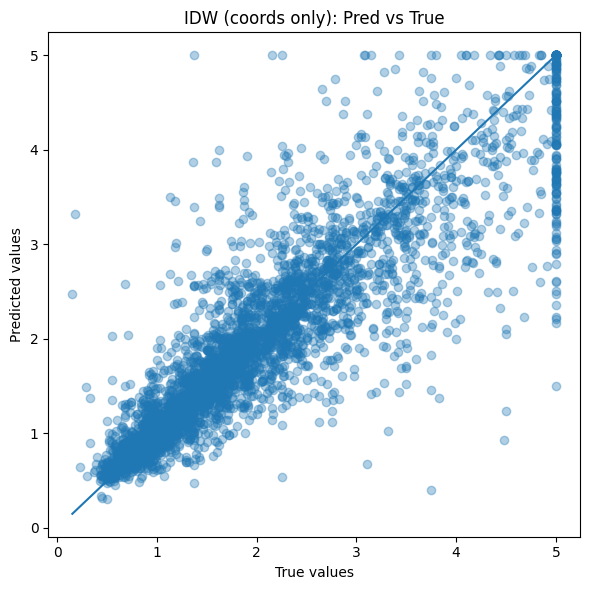

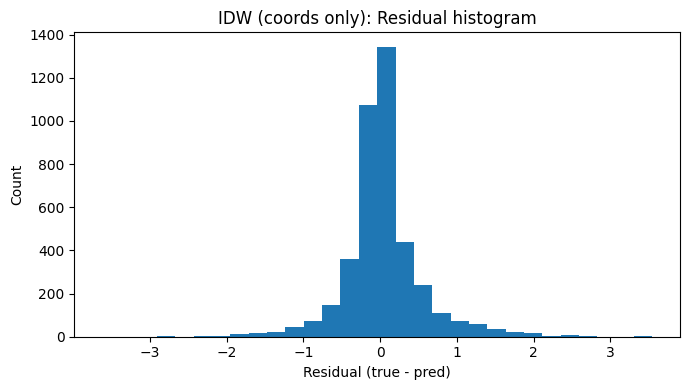

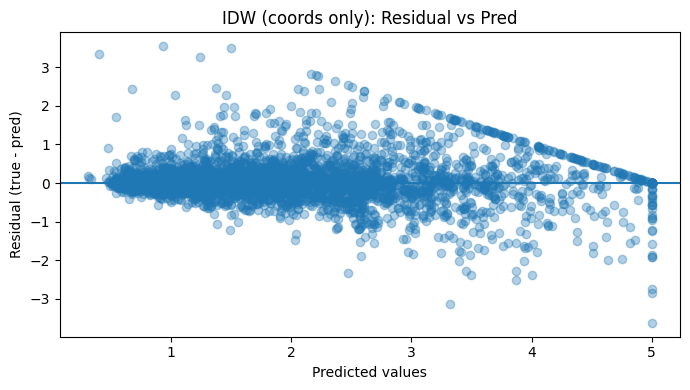

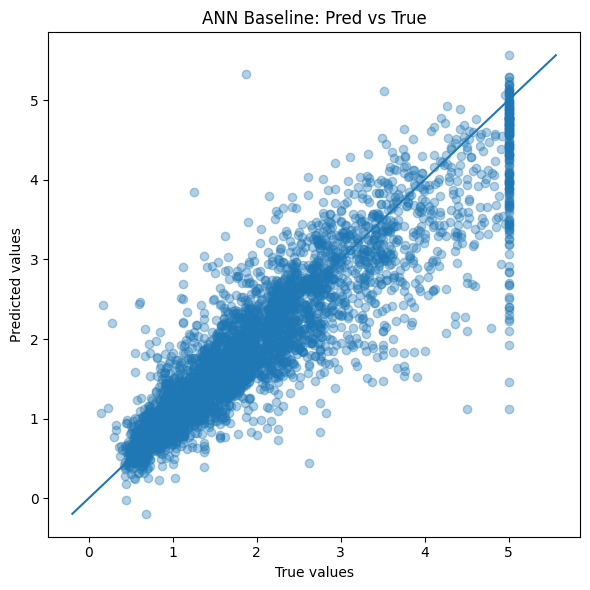

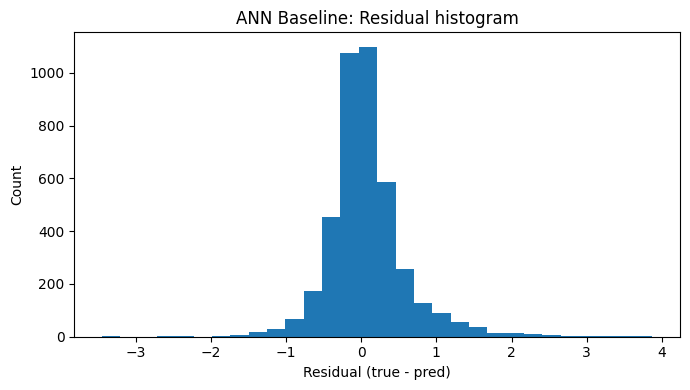

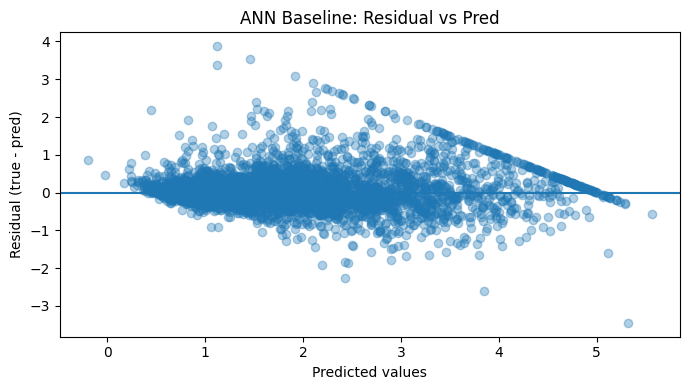

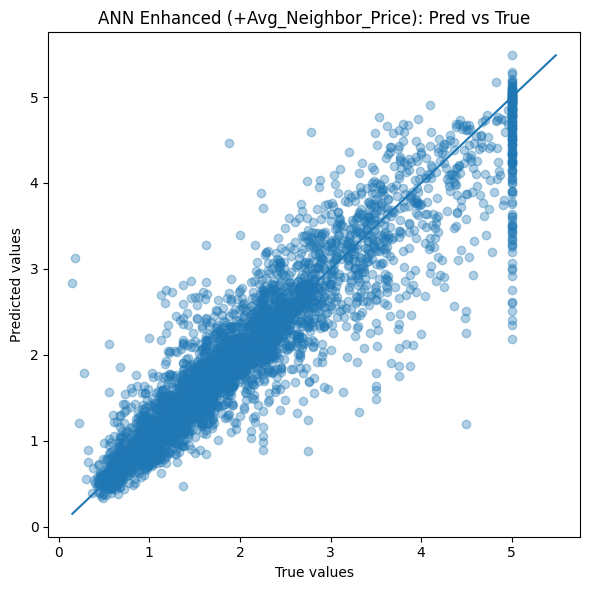

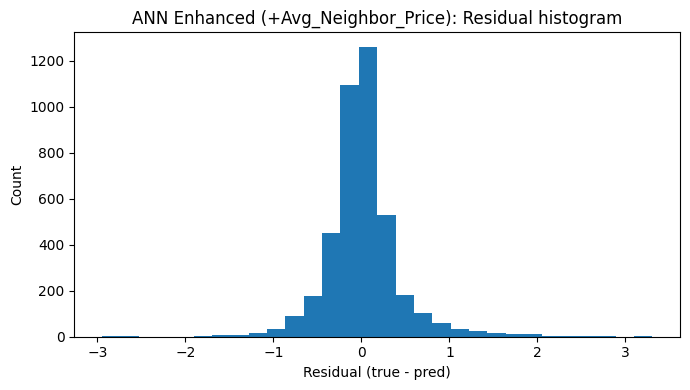

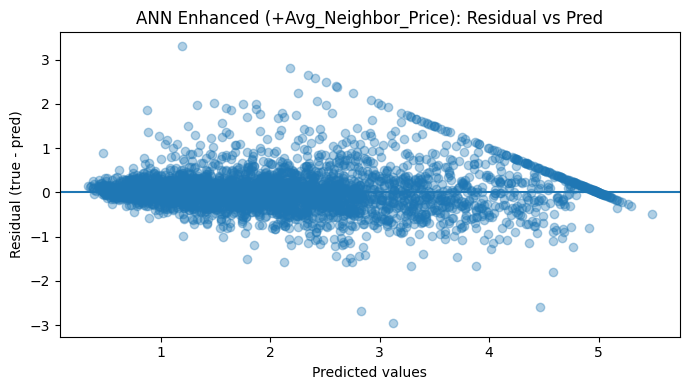

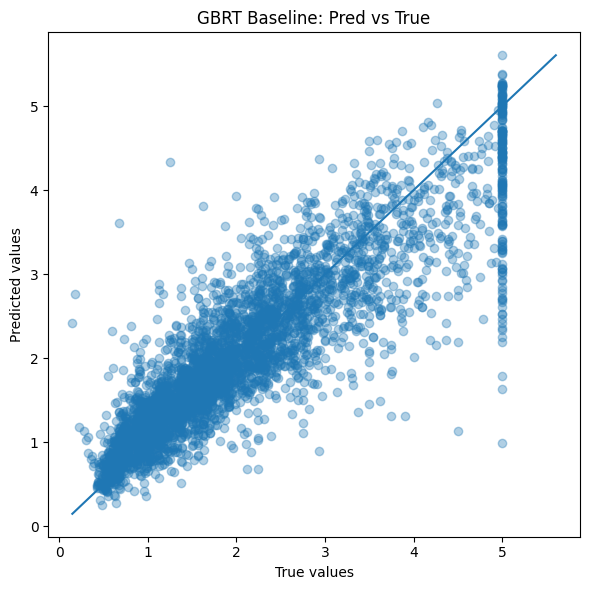

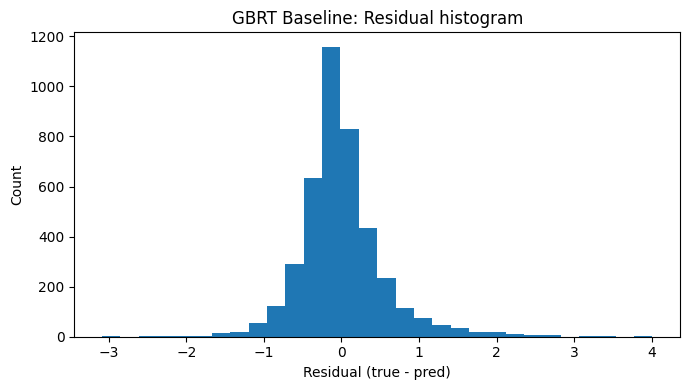

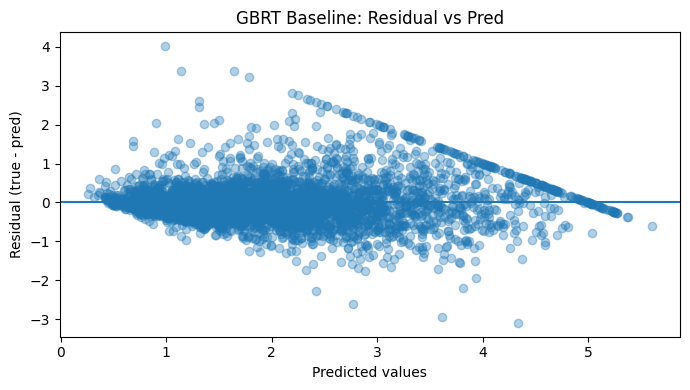

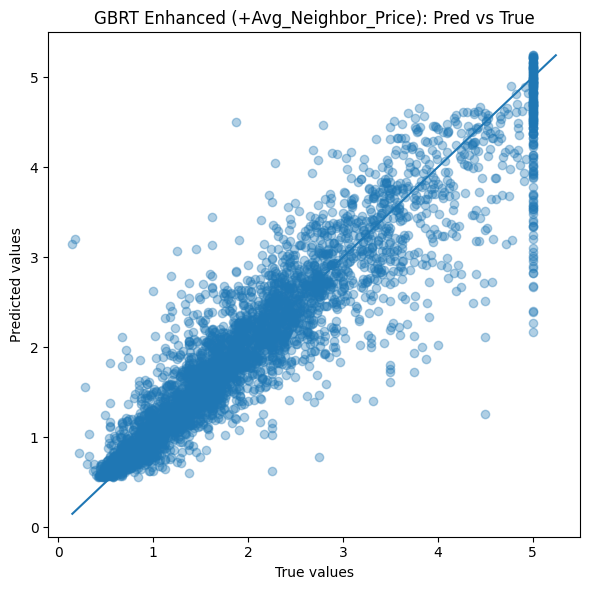

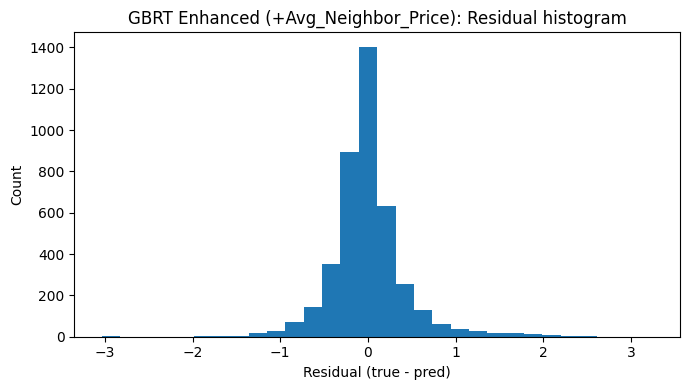

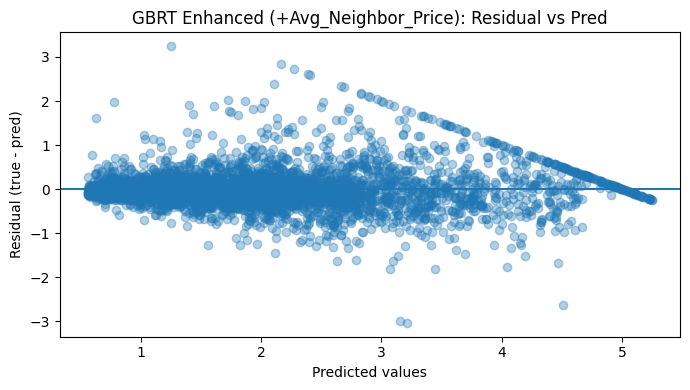

In [22]:

# --- (A) Per-model plots (run after you have the predictions) ---

# 1) IDW (coords only)
if 'y_pred_idw' in globals():
    plot_pred_vs_true(y_test, y_pred_idw, "IDW (coords only): Pred vs True")
    plot_residual_hist(y_test, y_pred_idw, "IDW (coords only): Residual histogram")
    plot_residual_vs_pred(y_test, y_pred_idw, "IDW (coords only): Residual vs Pred")

# 2) ANN baseline / enhanced
if 'y_pred_base' in globals():
    plot_pred_vs_true(y_test, y_pred_base, "ANN Baseline: Pred vs True")
    plot_residual_hist(y_test, y_pred_base, "ANN Baseline: Residual histogram")
    plot_residual_vs_pred(y_test, y_pred_base, "ANN Baseline: Residual vs Pred")

if 'y_pred_enh' in globals():
    plot_pred_vs_true(y_test, y_pred_enh, "ANN Enhanced (+Avg_Neighbor_Price): Pred vs True")
    plot_residual_hist(y_test, y_pred_enh, "ANN Enhanced (+Avg_Neighbor_Price): Residual histogram")
    plot_residual_vs_pred(y_test, y_pred_enh, "ANN Enhanced (+Avg_Neighbor_Price): Residual vs Pred")

# 3) Tree model (GBRT) baseline / enhanced
if 'y_pred_gbr_base' in globals():
    plot_pred_vs_true(y_test, y_pred_gbr_base, "GBRT Baseline: Pred vs True")
    plot_residual_hist(y_test, y_pred_gbr_base, "GBRT Baseline: Residual histogram")
    plot_residual_vs_pred(y_test, y_pred_gbr_base, "GBRT Baseline: Residual vs Pred")

if 'y_pred_gbr_en' in globals():
    plot_pred_vs_true(y_test, y_pred_gbr_en, "GBRT Enhanced (+Avg_Neighbor_Price): Pred vs True")
    plot_residual_hist(y_test, y_pred_gbr_en, "GBRT Enhanced (+Avg_Neighbor_Price): Residual histogram")
    plot_residual_vs_pred(y_test, y_pred_gbr_en, "GBRT Enhanced (+Avg_Neighbor_Price): Residual vs Pred")


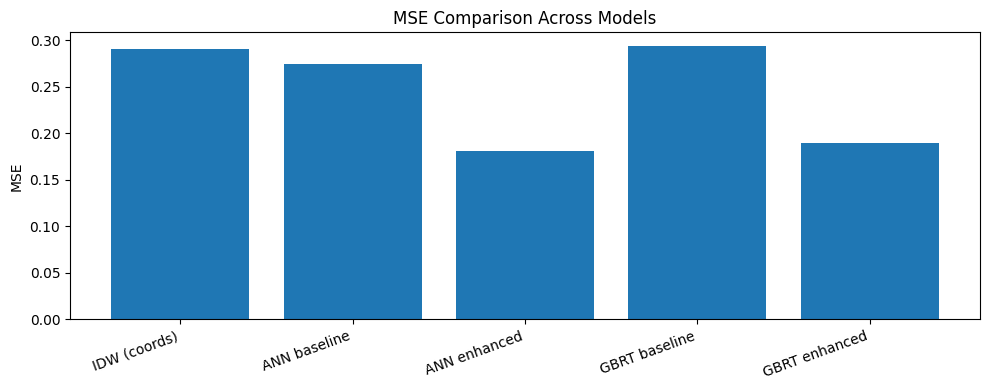

In [23]:

# --- (B) Overall MSE comparison bar chart (uses variables computed earlier) ---
mse_dict = {}
if 'mse_idw' in globals():       mse_dict["IDW (coords)"] = mse_idw
if 'mse_base' in globals():      mse_dict["ANN baseline"] = mse_base
if 'mse_enh' in globals():       mse_dict["ANN enhanced"] = mse_enh
if 'mse_gbr_base' in globals():  mse_dict["GBRT baseline"] = mse_gbr_base
if 'mse_gbr_en' in globals():    mse_dict["GBRT enhanced"] = mse_gbr_en

if len(mse_dict) > 0:
    bar_compare_mse(mse_dict, "MSE Comparison Across Models")
else:
    print("No MSE variables found yet. Run the model cells first.")


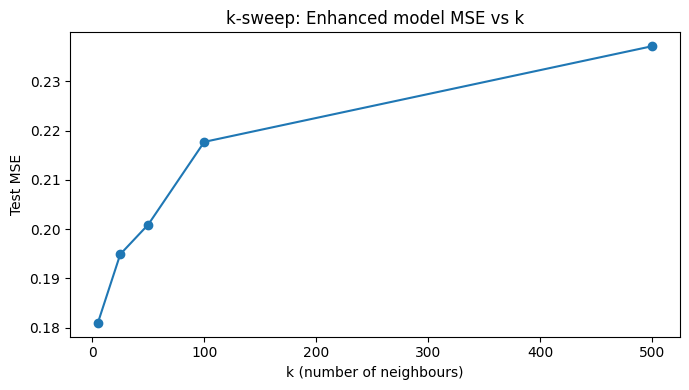

In [24]:

# --- (C) k-sweep plot (Section 10) ---
if 'k_results_df' in globals() and 'k' in k_results_df.columns:
    # In this notebook, k_results_df stores enhanced MSE across different k
    k_df = k_results_df.copy()
    # If it's already sorted by MSE, plot by k order
    k_df = k_df.sort_values('k')

    plt.figure(figsize=(7, 4))
    plt.plot(k_df['k'], k_df['test_mse'], marker='o')
    plt.xlabel("k (number of neighbours)")
    plt.ylabel("Test MSE")
    plt.title("k-sweep: Enhanced model MSE vs k")
    plt.tight_layout()
    plt.show()
else:
    print("k_results_df not found. Run Section 10 (k-sweep) first if you want this plot.")


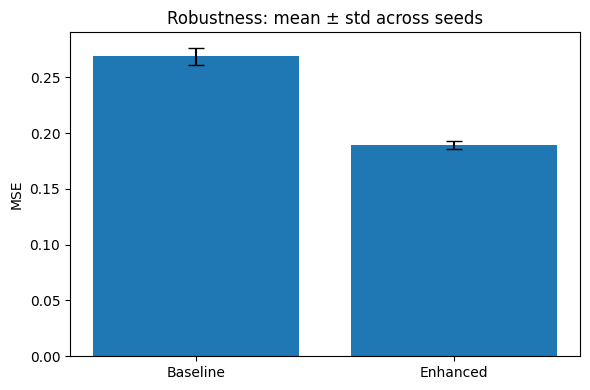

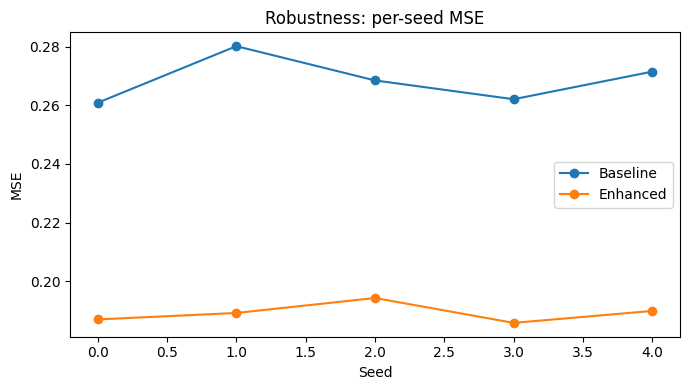

In [25]:

# --- (D) Robustness plots (Section 14) ---
if 'robust_df' in globals():
    # Error bar plot: mean ± std
    mean_b = robust_df['baseline_mse'].mean()
    std_b  = robust_df['baseline_mse'].std(ddof=1)
    mean_e = robust_df['enhanced_mse'].mean()
    std_e  = robust_df['enhanced_mse'].std(ddof=1)

    plt.figure(figsize=(6, 4))
    plt.bar(["Baseline", "Enhanced"], [mean_b, mean_e], yerr=[std_b, std_e], capsize=6)
    plt.ylabel("MSE")
    plt.title("Robustness: mean ± std across seeds")
    plt.tight_layout()
    plt.show()

    # Per-seed line plot
    plt.figure(figsize=(7, 4))
    plt.plot(robust_df['seed'], robust_df['baseline_mse'], marker='o')
    plt.plot(robust_df['seed'], robust_df['enhanced_mse'], marker='o')
    plt.xlabel("Seed")
    plt.ylabel("MSE")
    plt.title("Robustness: per-seed MSE")
    plt.legend(["Baseline", "Enhanced"])
    plt.tight_layout()
    plt.show()
else:
    print("robust_df not found. Run Section 14 first if you want robustness plots.")


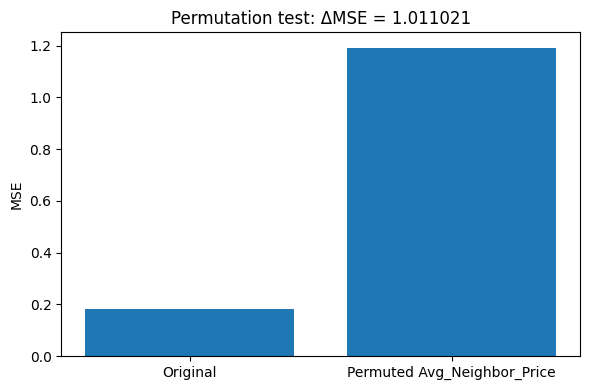

In [26]:

# --- (E) Permutation test visual (Section 15) ---
if 'mse_perm' in globals() and 'mse_enh' in globals():
    delta = mse_perm - mse_enh
    plt.figure(figsize=(6, 4))
    plt.bar(["Original", "Permuted Avg_Neighbor_Price"], [mse_enh, mse_perm])
    plt.ylabel("MSE")
    plt.title(f"Permutation test: ΔMSE = {delta:.6f}")
    plt.tight_layout()
    plt.show()
else:
    print("Permutation MSE variables not found. Run Section 15 first if you want this plot.")


## Discussion  
1. Enhanced 的动机与效果（baseline vs enhanced）

本项目的核心问题是：在用 ANN（MLPRegressor）预测房价时，加入“邻域/图结构”的信息是否能提高预测效果。Baseline 模型只使用原始的 8 个特征来训练，其中虽然已经包含纬度（Latitude）和经度（Longitude），但把经纬度当作普通数值输入时，神经网络仍需要自己学习复杂的“位置→房价”的非线性映射，训练难度较高、对样本局部结构的利用也不直接。  
因此我们构造了 enhanced 模型：利用经纬度通过 kNN 找到每个样本的邻居，并用训练集邻居的房价均值构造新特征 **Avg_Neighbor_Price**，再与原始特征一起输入 ANN。这个特征的直觉是：地理位置相近的地区通常房价也相近（空间相关性）。从上文的 MSE 输出与 Actual vs Predicted 点云图对比可以看到：enhanced 模型整体更贴近 y=x 参考线，并且测试误差相对 baseline 有改善（具体数值见对应代码单元格输出）。  



**补充证据链：空间基线 + 可解释性 + 稳健性**  
为避免“我们只是做了一个工程 trick”的质疑，我们增加了三类对照：  
- **IDW 空间基线**（只用经纬度）：用反距离加权平均直接从训练集邻居房价做预测，作为“纯空间相关性”的下限基准。与 enhanced ANN 对比，可以更清楚地区分“简单空间平滑”与“学习模型 + 邻域特征”的增益。  
- **Permutation test**：只打乱测试集的 Avg_Neighbor_Price，观察 enhanced ANN 的 MSE 是否显著上升，从而验证该特征对模型预测的实质贡献。  
- **重复随机划分**：用多个随机种子重复 train/test split，汇总 baseline vs enhanced 的 MSE 与提升比例（mean ± std），用于检验结论的稳定性与可复现性。  
上述三项结果见上方对应代码单元格输出。

2. cap=5（目标封顶）带来的误差结构

从 Actual vs Predicted 图中可以看到在 Actual≈5 附近存在明显的竖直带，这提示目标变量在最大值处存在封顶/截断（censoring）。这种封顶会限制模型学习最高价区域的细粒度差异：因为数据把超过上限的真实价格统一记为 5，模型无法区分 5 以上的真实价格梯度。  
因此，高价端往往成为主要误差来源，也解释了为什么图上 Actual≈5 附近点云更分散、预测偏差更大。

3. k-sweep 结论（为什么 k 太大变差）

为了进一步改进 enhanced 模型，我们把邻居数 k 当成可调参数，测试了多个 k 值。直观上，较小的 k 代表更“局部”的邻域信息，而较大的 k 会更“平滑”，更像区域平均水平。实验中，不同 k 的点云图整体形状相似，说明模型对中等范围的 k 变化不是极度敏感；但从 MSE 数值仍能观察到差异：当 k 过大时，误差往往上升。一个合理解释是 **过度平滑（over-smoothing）**：当邻域范围太大，邻居点可能来自不同的城市/不同的经济区，均值会抹平真实的局部地段差异，使 Avg_Neighbor_Price 的“本地信息”下降，最终影响泛化表现。因此较小的 k（例如 5 或 25）更像是“局部性”和“稳定性”之间的折中。  

4. Distance-weighted 尝试：更复杂 ≠ 更好

我们进一步尝试把简单平均改为距离加权平均：离得越近的邻居权重越大，希望更符合“越近越相关”的直觉。但从实验输出可见，距离加权并不稳定，部分设置下测试 MSE 反而更高。  
可能原因包括：  
- 距离度量误差：这里用经纬度直接做欧氏距离近似，并不等价于真实地理距离；  
- 权重过“尖锐”：1/(d+eps) 会让最近的 1–2 个邻居主导特征，噪声或市场边界效应会被放大；  
- 在这种情况下，简单均值反而更平滑、更抗噪，作为 ANN 输入时更稳健。

5. 拓展模型对照（树模型 GBRT）：验证“邻域特征”的普适性

为了确认邻域特征的价值是否只对 ANN 有效，我们加入了 Gradient Boosting Regressor（树模型）作为对照。树模型不依赖特征缩放，且擅长非线性与特征交互。上文结果显示：在树模型上加入 Avg_Neighbor_Price 也能带来一定程度的误差改善（具体 MSE 与提升比例见对应输出）。这说明邻域信息提供的“局部价格基准”具有一定普适性，而不仅仅是对 MLP 的工程 trick。  

6. 局限性 + future work

- 邻域关系仅基于经纬度 KNN，没有考虑真实地理距离、道路/地形阻隔或行政边界，导致“邻居”不一定属于同一房价子市场。  
- 邻域统计目前只使用均值（或加权均值），可进一步加入邻居房价的标准差、min/max、分位数等描述局部波动的信息，或做真正的多尺度特征（同时输入多个 k 的统计量）。  
- 目标封顶（cap=5）使高价区间先天难评估；未来可分价格区间报告 MAE/RMSE，或用更合适的目标变换与评估指标。  
- 我们已做多随机种子重复划分的稳健性检查；未来可进一步做 **空间分组交叉验证（spatial CV）**，避免地理上相近样本同时出现在 train/test 中导致的乐观估计。


## 总结
这份 notebook 的目标是：在 California Housing 回归任务中，比较 **Baseline（只用原始特征）** 与 **Enhanced（加入邻域特征）** 的预测效果，并通过一系列实验解释结果背后的原因。

(1) Baseline ANN（不加邻域特征）  
我们先用原始 8 个特征训练一个 ANN 回归模型（MLPRegressor），用测试集 MSE 评估效果，并画出 Actual vs Predicted 点云图作为直观诊断。

(2) Enhanced ANN：加入邻域特征（Avg_Neighbor_Price）  
利用纬度/经度通过 kNN 找邻居，并用训练集邻居的房价均值构造新特征 Avg_Neighbor_Price，再与原始特征一起输入 ANN。  
为了避免 data leakage，测试集的邻域特征只用训练集的 y_train 计算，不使用 y_test。对比输出与点云图可见：加入邻域特征后整体误差下降、点云更贴近 y=x（具体数值见对应输出）。

(3) 改进尝试 1：调整 k（邻居数）  
我们对多个 k 值重复“构造邻域特征 → 标准化 → 训练 ANN → 计算 MSE”，发现存在更优的局部尺度：k 太大时会 over-smoothing，抹平本地差异；k 太小则可能更受噪声影响。

(4) 改进尝试 2：距离加权邻域均值（Weighted_Neighbor_Price）  
进一步尝试用 1/(d+eps) 做距离加权平均。结果表明更复杂的加权并不一定更好：它对距离度量误差更敏感，并可能被最近邻噪声主导，导致泛化变差。

(5) 拓展模型：Gradient Boosting（树模型）对照  
为了验证邻域特征的普适性，我们加入树模型（GBRT）进行 baseline vs enhanced 对比。输出显示：在树模型上加入 Avg_Neighbor_Price 同样可能带来一定提升，说明邻域信息提供的“局部价格基准”具有可迁移价值，而不仅限于 ANN。



(4) 证据补强：空间基线 + 稳健性 + 可解释性  
- 我们加入 **IDW（只用经纬度）** 作为极简空间基线，帮助判断“纯空间平滑”能做到什么程度，并与 enhanced 模型形成对照。  
- 我们用多个随机种子重复划分数据，汇总 baseline/enhanced 的 MSE 与提升比例（mean ± std），验证结论并非偶然划分造成。  
- 我们对测试集的 **Avg_Neighbor_Price** 做 permutation test：只打乱这一列，观察 enhanced ANN 的 MSE 上升幅度，用于验证该特征对预测确实重要。  

总体而言，加入邻域统计特征能够显著利用房价的空间相关性，使模型更容易捕捉“局部价格基准”，从而提升泛化表现；同时，对 k 的选择与距离加权形式需要权衡平滑程度与噪声放大风险。